In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
from darts import TimeSeries
from darts.models import LinearRegressionModel, ExponentialSmoothing, ARIMA, AutoARIMA

In [ ]:
df_pivot = pd.read_csv('../data/Daily_Means_Through_2022_cleaned_NEW.csv')
df_pivot

In [ ]:
# housekeeping
df_pivot['date'] = pd.to_datetime(df_pivot['date'])
df_new = df_pivot.sort_values(by=['site', 'date'])
df_new

In [ ]:
# so BR is NOT continous

df = df_new[df_new['site'] == 'GD']
# drop observation if do is na
#df = df.dropna(subset=['bottom_DO_mg/L'])
df = df.dropna(subset=['surface_DO_mg/L'])
bottom_cols = [col for col in df.columns if 'bottom' in col]

df.drop(columns=bottom_cols, inplace=True)
df.drop(columns=['site'], inplace=True)
print(df.isnull().sum())
print(df)

In [ ]:
ts = TimeSeries.from_dataframe(df, time_col='date', freq='D', fill_missing_dates=True)
ts

In [ ]:
# back to dataframe
df = ts.pd_dataframe()
df

In [ ]:
print(df.isnull().sum())
print(df)

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression


In [ ]:
lr = LinearRegression()
imp = IterativeImputer(estimator=lr, verbose=2, max_iter=10, tol=1e-10, imputation_order='roman')
ImputedData = imp.fit_transform(df)
ImputedData = pd.DataFrame(ImputedData, columns=df.columns)
print(ImputedData.isnull().sum())
print(ImputedData)

In [ ]:
ImputedData["date"] = df.index
ImputedData

In [ ]:
# ts
ts = TimeSeries.from_dataframe(ImputedData, time_col='date', freq='D', fill_missing_dates=True)
ts

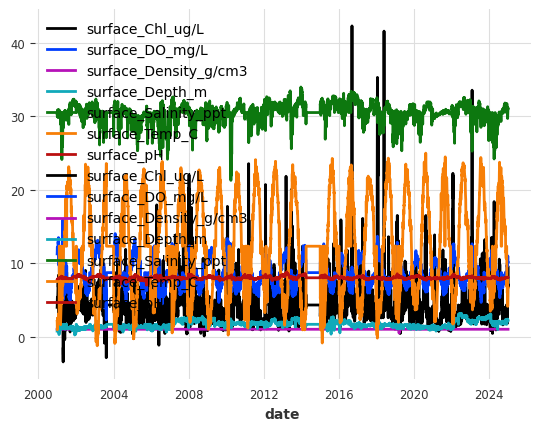

In [ ]:
train, val = ts.split_after(pd.Timestamp('2019-01-01'))
train.plot()
val.plot()

In [ ]:
# build linear regression model
lr = LinearRegressionModel(lags=2, lags_past_covariates=2, output_chunk_length=14)
#lr.fit(train["surface_DO_mg/L"], past_covariates=train.drop_columns("surface_DO_mg/L"))
lr.fit(ts["surface_DO_mg/L"], past_covariates=ts.drop_columns("surface_DO_mg/L"))

In [ ]:
# test + 2weeks 


In [ ]:
forecast = lr.predict(len(val), past_covariates=train.drop_columns("surface_DO_mg/L").append(val.drop_columns("surface_DO_mg/L")))
ts["surface_DO_mg/L"].plot()
forecast.plot()
plt.show()

In [ ]:
# check forecast
from darts.metrics import mape
mape_val = mape(val["surface_DO_mg/L"], forecast)
print(f'MAPE: {mape_val:.2f}%')

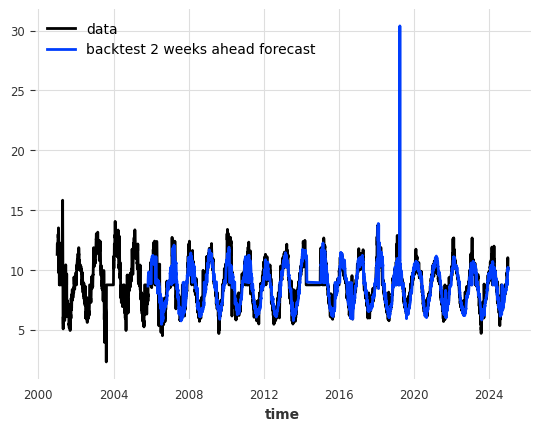

In [ ]:
hfc_params = {
    "series": ts["surface_DO_mg/L"],
    "start": 0.2,  # can also be a float for the fraction of the series to start at
    "forecast_horizon": 14,
    "verbose": True,
}
historical_fcast = lr.historical_forecasts(
  past_covariates = ts.drop_columns("surface_DO_mg/L"), **hfc_params
)

ts["surface_DO_mg/L"].plot(label="data")
historical_fcast.plot(label="backtest 2 weeks ahead forecast")
print(f"MAPE = {mape(ts["surface_DO_mg/L"], historical_fcast):.2f}%")

In [ ]:
from darts.models import XGBModel

xg = XGBModel(
    lags=2,
    lags_past_covariates=2,
    output_chunk_length=14,
    n_jobs=-1,
    random_state=42,
)

xg.fit(ts["surface_DO_mg/L"], past_covariates=ts.drop_columns("surface_DO_mg/L"))


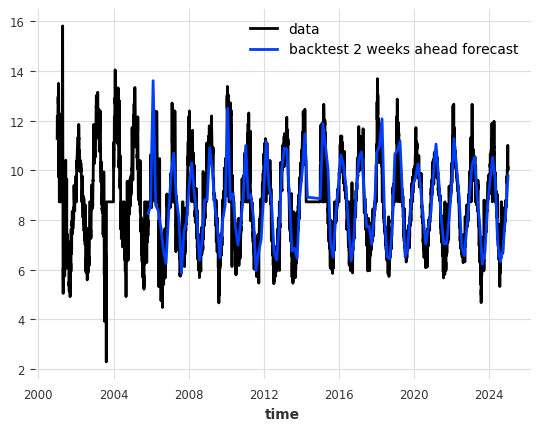

In [ ]:
hfc_params = {
    "series": ts["surface_DO_mg/L"],
    "start": 0.2,  # can also be a float for the fraction of the series to start at
    "forecast_horizon": 14,
    "verbose": True,
    "stride": 50,
}
historical_fcast = xg.historical_forecasts(
  past_covariates = ts.drop_columns("surface_DO_mg/L"), **hfc_params
)

ts["surface_DO_mg/L"].plot(label="data")
historical_fcast.plot(label="backtest 2 weeks ahead forecast")
print(f"MAPE = {mape(ts["surface_DO_mg/L"], historical_fcast):.2f}%")

In [ ]:
ts_only_do = ts["surface_DO_mg/L"]
ts

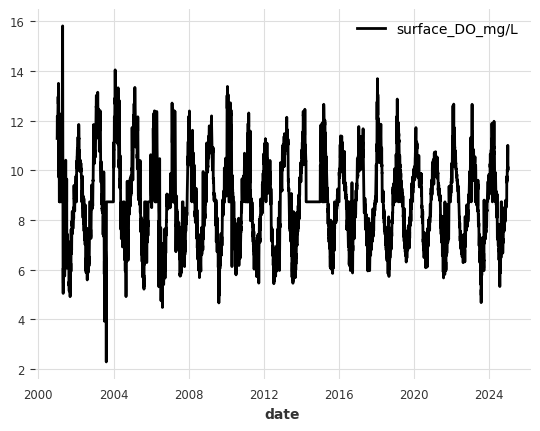

In [ ]:
ts_only_do.plot()

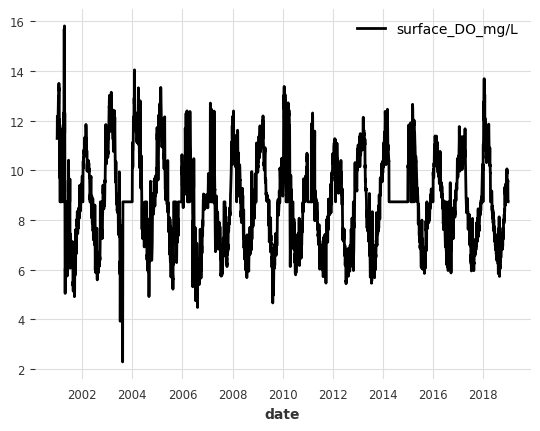

In [ ]:
train, val = ts_only_do.split_after(pd.Timestamp('2019-01-01'))
train.plot()

In [ ]:
from darts.models import ExponentialSmoothing, StatsForecastAutoARIMA
from darts.utils.utils import ModelMode, SeasonalityMode

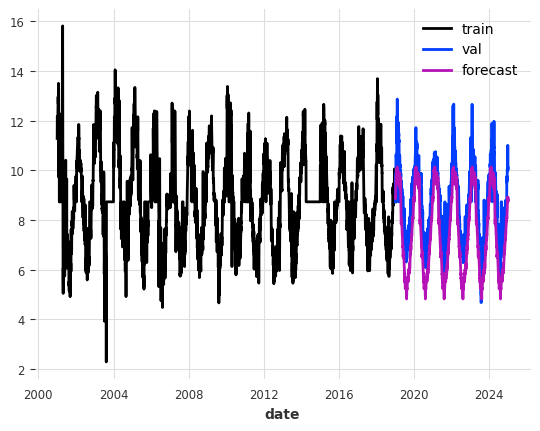

In [ ]:
# Exponential Smoothing
exp = ExponentialSmoothing(trend=ModelMode.NONE, seasonal=SeasonalityMode.ADDITIVE, seasonal_periods=365)
exp.fit(train)
forecast = exp.predict(len(val))
train.plot(label="train")
val.plot(label="val")
forecast.plot(label="forecast")
plt.legend()


In [ ]:
# mape 
mape_val = mape(val, forecast)
print(f'MAPE: {mape_val:.2f}%')

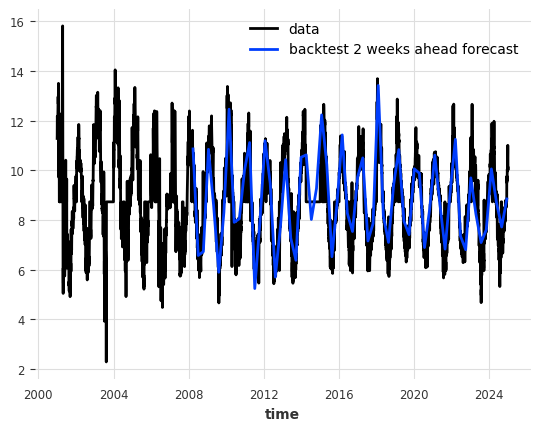

In [ ]:
hfc_params = {
    "series": ts_only_do,
    "start": 0.3,  # can also be a float for the fraction of the series to start at
    "forecast_horizon": 14,
    "verbose": True,
    "stride": 100,
}
historical_fcast = exp.historical_forecasts(
   **hfc_params
)

ts["surface_DO_mg/L"].plot(label="data")
historical_fcast.plot(label="backtest 2 weeks ahead forecast")
print(f"MAPE = {mape(ts["surface_DO_mg/L"], historical_fcast):.2f}%")

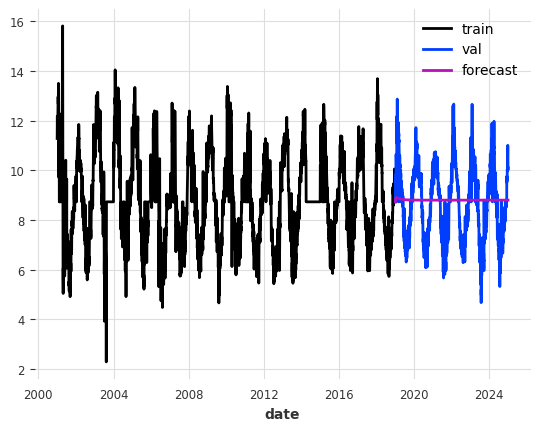

In [ ]:
aa = StatsForecastAutoARIMA(
    seasonal=True,
    stepwise=True,
)

aa.fit(train)
forecast = aa.predict(len(val))
train.plot(label="train")
val.plot(label="val")
forecast.plot(label="forecast")

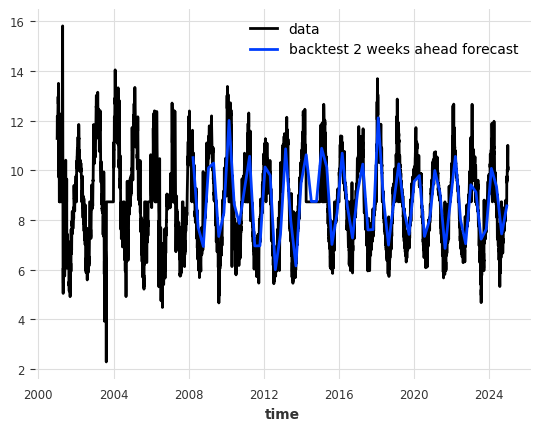

In [ ]:
hfc_params = {
    "series": ts_only_do,
    "start": 0.3,  # can also be a float for the fraction of the series to start at
    "forecast_horizon": 14,
    "verbose": True,
    "stride": 100,
}
historical_fcast = aa.historical_forecasts(
   **hfc_params
)

ts["surface_DO_mg/L"].plot(label="data")
historical_fcast.plot(label="backtest 2 weeks ahead forecast")
print(f"MAPE = {mape(ts["surface_DO_mg/L"], historical_fcast):.2f}%")